In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [4]:
df=pd.read_csv("creditcard.csv")
print(df.head())
print(df.shape)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
    )

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [8]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Class
0    199020
1       344
Name: count, dtype: int64
Class
0    199020
1    199020
Name: count, dtype: int64


In [9]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

In [10]:
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [18]:
y_probability = model.predict_proba(X_test)[:, 1]
y_pred = (y_probability >= 0.50).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9968    0.9983     85295
           1     0.3159    0.8581    0.4618       148

    accuracy                         0.9965     85443
   macro avg     0.6578    0.9274    0.7300     85443
weighted avg     0.9986    0.9965    0.9973     85443



In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[85020   275]
 [   21   127]]


In [13]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)
print(feature_importance)

   Feature  Importance
27     V27    0.004816
6       V6    0.006002
20     V20    0.006301
25     V25    0.006363
2       V2    0.006413
24     V24    0.006479
5       V5    0.007158
23     V23    0.007668
22     V22    0.007956
16     V16    0.008287
29  Amount    0.008429
19     V19    0.008658
9       V9    0.009889
15     V15    0.010512
0     Time    0.010956
26     V26    0.011333
21     V21    0.011341
18     V18    0.011582
1       V1    0.011674
7       V7    0.013894
28     V28    0.014876
13     V13    0.015052
3       V3    0.015716
11     V11    0.016580
8       V8    0.017178
12     V12    0.036702
17     V17    0.050514
4       V4    0.053181
10     V10    0.082081
14     V14    0.522411


In [20]:
roc_auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC:", round(roc_auc, 4))

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred = (y_probability >= t).astype(int)
    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred, digits=4))

ROC-AUC: 0.9722

Threshold: 0.5
              precision    recall  f1-score   support

           0     0.9998    0.9968    0.9983     85295
           1     0.3159    0.8581    0.4618       148

    accuracy                         0.9965     85443
   macro avg     0.6578    0.9274    0.7300     85443
weighted avg     0.9986    0.9965    0.9973     85443


Threshold: 0.4
              precision    recall  f1-score   support

           0     0.9998    0.9951    0.9974     85295
           1     0.2332    0.8649    0.3673       148

    accuracy                         0.9948     85443
   macro avg     0.6165    0.9300    0.6823     85443
weighted avg     0.9984    0.9948    0.9963     85443


Threshold: 0.3
              precision    recall  f1-score   support

           0     0.9998    0.9926    0.9962     85295
           1     0.1689    0.8649    0.2826       148

    accuracy                         0.9924     85443
   macro avg     0.5843    0.9287    0.6394     85443
weighted a

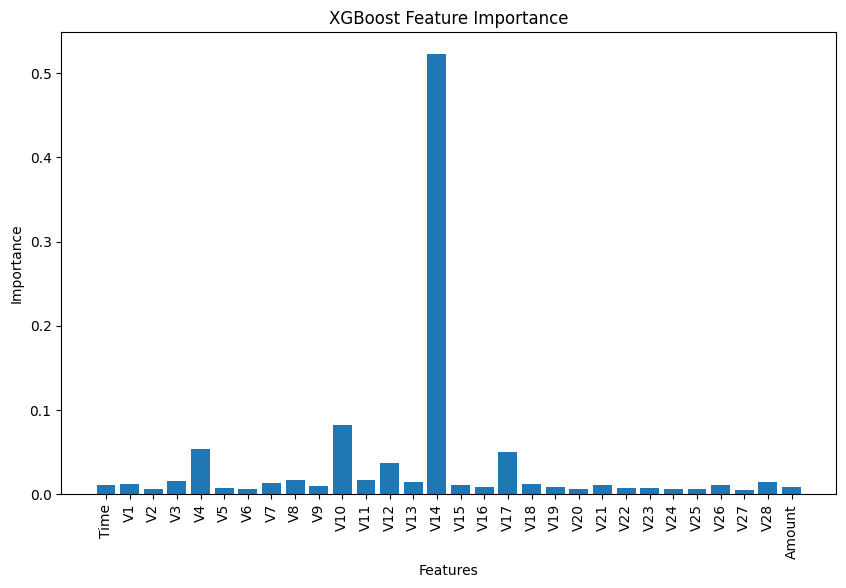

In [22]:
importance = model.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
plt.bar(features, importance)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()